### ***Yolov11 :*** YOLOv11 is the latest state-of-the-art model in the "You Only Look Once" (YOLO) family for real-time computer vision.

- the latest state-of-the-art model in the You Only Look Once (YOLO) family for real-time computer vision. Released by Ultralytics, it is designed to pinpoint and classify objects in images and videos with exceptional speed and accuracy. It achieves higher precision while using fewer computational parameters than older versions.

### Key Architectural Upgrades
- YOLOv11 introduces several structural advancements designed to make the model "smarter" and lighter:
- ***Enhanced Feature Extraction:*** It replaces older modules with advanced C3k2 blocks to analyze spatial features without blowing up the parameter count.
- ***Spatial Attention:*** It incorporates the C2PSA block, a cross-stage partial attention mechanism that allows the model to focus on the most critical parts of an image. This significantly improves the detection of tiny objects or targets that overlap.
- ***Better Efficiency:*** YOLOv11 delivers a higher mean Average Precision (mAP) while using roughly 22% fewer parameters than models like YOLOv8m

## Infercing with Pretrained YOLO Models

Inastalling ultralytics

In [1]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.1/112.6 GB disk)


### using YOLO pretrained Models for Prediction

In [2]:
## Visual The image funtion\
import cv2
from google.colab.patches import cv2_imshow

def image_show(image_path):
  image = cv2.imread(image_path)
  if image is None:
    print("Error : Image is not found")
    return

  cv2_imshow(image)


# Inferecing with YOLOv11 Pretrained Model

In [10]:
## Run Inferecing on an image with YOLO11n
!yolo predict model=yolo11n.pt source="https://www.shutterstock.com/image-photo/young-africanamerican-female-medical-worker-260nw-2524838017.jpg"

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

image 1/1 /content/young-africanamerican-female-medical-worker-260nw-2524838017.jpg: 480x640 2 persons, 1 car, 50.7ms
Speed: 3.7ms preprocess, 50.7ms inference, 16.8ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict-2
💡 Learn more at https://docs.ultralytics.com/modes/predict


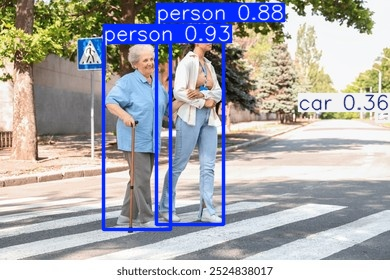

In [17]:
image_show('/content/runs/detect/predict-2/young-africanamerican-female-medical-worker-260nw-2524838017.jpg')


2

In [19]:
!yolo predict model=yolo11n.pt source="https://c8.alamy.com/comp/2BJPY9B/young-woman-helping-elderly-man-with-walking-frame-to-cross-the-road-2BJPY9B.jpg"

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

image 1/1 /content/young-woman-helping-elderly-man-with-walking-frame-to-cross-the-road-2BJPY9B.jpg: 544x640 5 persons, 1 car, 49.6ms
Speed: 3.6ms preprocess, 49.6ms inference, 17.7ms postprocess per image at shape (1, 3, 544, 640)
Results saved to /content/runs/detect/predict-4
💡 Learn more at https://docs.ultralytics.com/modes/predict


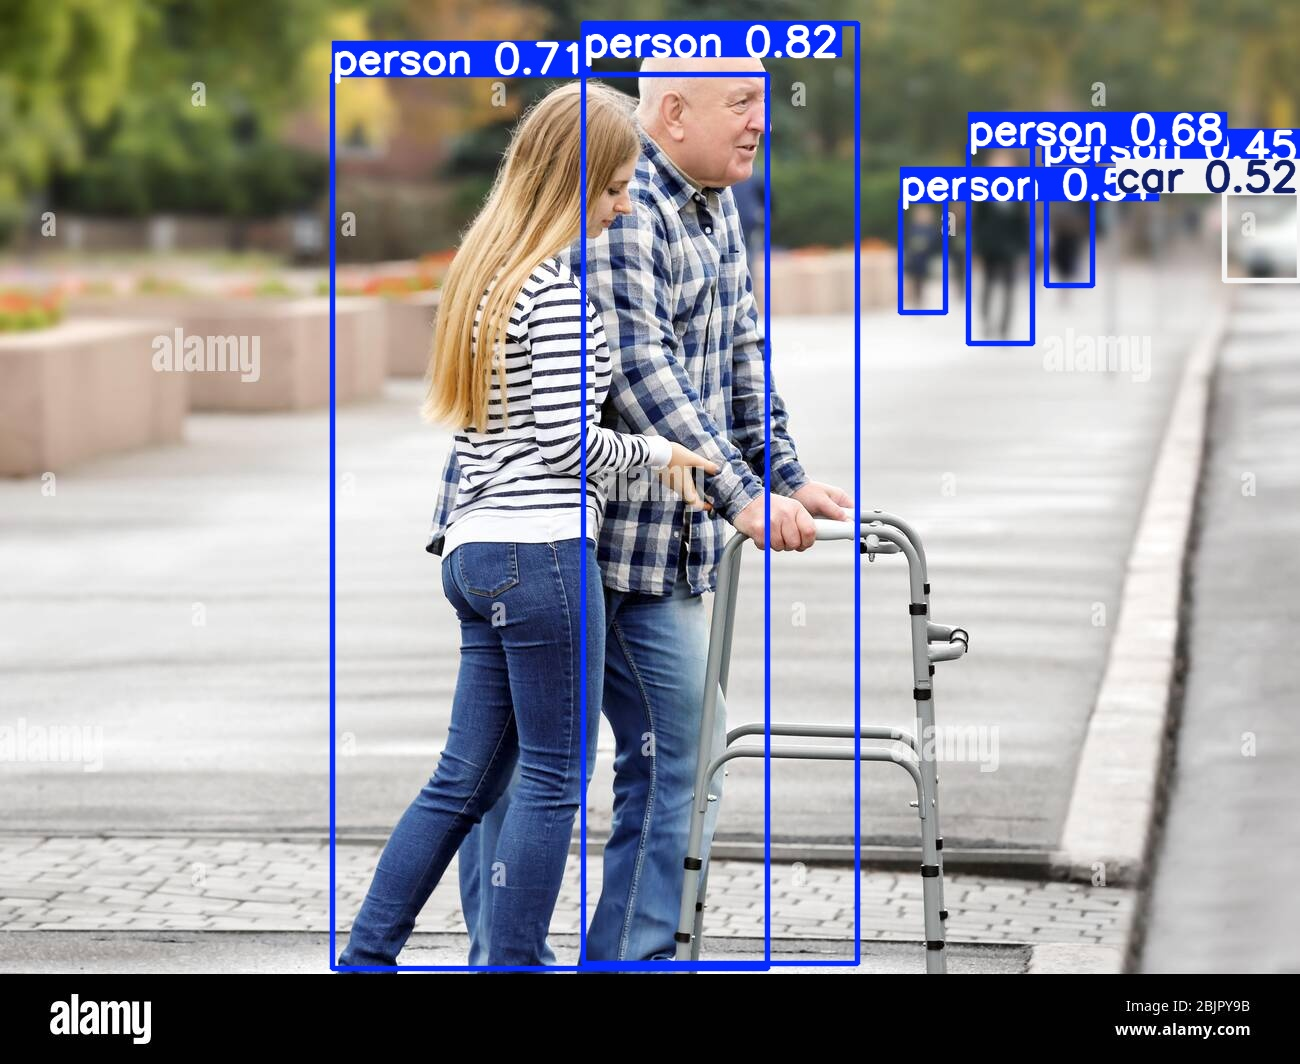

In [26]:
image_show("/content/runs/detect/predict-4/young-woman-helping-elderly-man-with-walking-frame-to-cross-the-road-2BJPY9B.jpg")

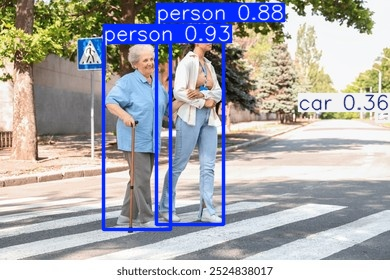

In [27]:
image_show("/content/runs/detect/predict-3/young-africanamerican-female-medical-worker-260nw-2524838017.jpg")

## python Usage

In [29]:
from ultralytics import YOLO

## Load YOLO model
model = YOLO("yolo11n.pt") ##3 Load an official model

In [32]:
### Predict with the model
results = model("https://c8.alamy.com/comp/2BJPY9B/young-woman-helping-elderly-man-with-walking-frame-to-cross-the-road-2BJPY9B.jpg")


Found https://c8.alamy.com/comp/2BJPY9B/young-woman-helping-elderly-man-with-walking-frame-to-cross-the-road-2BJPY9B.jpg locally at young-woman-helping-elderly-man-with-walking-frame-to-cross-the-road-2BJPY9B.jpg
image 1/1 /content/young-woman-helping-elderly-man-with-walking-frame-to-cross-the-road-2BJPY9B.jpg: 544x640 5 persons, 1 car, 8.7ms
Speed: 2.8ms preprocess, 8.7ms inference, 1.5ms postprocess per image at shape (1, 3, 544, 640)


In [33]:
## # Access the results
for i, result in enumerate(results):
    print(f"\nResult {i + 1}:")

    xywh = result.boxes.xywh  # ## center-x, center-y, width, height
    print("  Bounding Boxes (xywh):")
    print(xywh)

    xywhn = result.boxes.xywhn  # normalized
    print("  Normalized Bounding Boxes (xywhn):")
    print(xywhn)

    xyxy = result.boxes.xyxy  # top-left-x, top-left-y, bottom-right-x, bottom-right-y
    print("  Bounding Boxes (xyxy):")
    print(xyxy)

    xyxyn = result.boxes.xyxyn  # normalized
    print("  Normalized Bounding Boxes (xyxyn):")
    print(xyxyn)

    names = [result.names[cls.item()] for cls in result.boxes.cls.int()]  # class name of each box
    print("  Class Names:")
    print(names)

    confs = result.boxes.conf  # confidence score of each box
    print("  Confidence Scores:")
    print(confs)


Result 1:
  Bounding Boxes (xywh):
tensor([[ 720.6623,  493.5311,  274.1622,  940.2800],
        [ 549.9639,  521.1614,  434.8063,  893.7737],
        [1000.7646,  244.4309,   64.3254,  197.8169],
        [1261.7140,  236.5009,   75.2058,   87.3618],
        [ 923.3309,  256.3035,   44.8284,  112.2835],
        [1069.2711,  224.0469,   46.4553,  122.1436]], device='cuda:0')
  Normalized Bounding Boxes (xywhn):
tensor([[0.5544, 0.4638, 0.2109, 0.8837],
        [0.4230, 0.4898, 0.3345, 0.8400],
        [0.7698, 0.2297, 0.0495, 0.1859],
        [0.9705, 0.2223, 0.0579, 0.0821],
        [0.7103, 0.2409, 0.0345, 0.1055],
        [0.8225, 0.2106, 0.0357, 0.1148]], device='cuda:0')
  Bounding Boxes (xyxy):
tensor([[ 583.5812,   23.3911,  857.7434,  963.6711],
        [ 332.5608,   74.2745,  767.3671,  968.0482],
        [ 968.6020,  145.5224, 1032.9274,  343.3393],
        [1224.1111,  192.8200, 1299.3169,  280.1817],
        [ 900.9167,  200.1618,  945.7451,  312.4453],
        [1046.0435, 